# 第 5 章 · 图搜索代码实验

[章节网页](../ch5.html)

## 运行内容

- 构建校园路径图和邻接表
- 实现 DFS、BFS、UCS、Greedy、A*
- 查看每个算法的展开过程、路径图和代价

## 0. 数据与画图

In [1]:
# 导入实验所需库，并设置图表中文显示。
import importlib.util
import logging
import subprocess
import sys
import warnings
from collections import deque
import heapq
from pathlib import Path

required_packages = {
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 构建校园路径图：nodes 是地点信息，edges 是道路与代价。
graph = {
    "start": "x",
    "goal": "c1",
    "nodes": {
        "x": {"name": "校门口", "h": 7},
        "c2": {"name": "超市", "h": 1},
        "j": {"name": "教学楼", "h": 4},
        "s2": {"name": "实验楼", "h": 4},
        "s1": {"name": "食堂", "h": 3},
        "t": {"name": "图书馆", "h": 2},
        "c1": {"name": "操场", "h": 0},
    },
    "edges": [
        {"from": "x", "to": "c2", "cost": 7},
        {"from": "x", "to": "j", "cost": 2},
        {"from": "x", "to": "s1", "cost": 2},
        {"from": "j", "to": "s2", "cost": 4},
        {"from": "s2", "to": "s1", "cost": 1},
        {"from": "s1", "to": "t", "cost": 3},
        {"from": "s1", "to": "c1", "cost": 6},
        {"from": "t", "to": "c1", "cost": 2},
    ],
}

start = graph["start"]
goal = graph["goal"]
h = {node: meta["h"] for node, meta in graph["nodes"].items()}
print("start:", start, "goal:", goal)

start: x goal: c1


In [3]:
# 把边表转成邻接表：搜索算法只需要知道“当前节点能走向哪些邻居”。
adj = {}
for edge in graph["edges"]:
    a = edge["from"]
    b = edge["to"]
    cost = edge["cost"]
    adj.setdefault(a, []).append((b, cost))
    adj.setdefault(b, []).append((a, cost))

for neighbors in adj.values():
    neighbors.sort(key=lambda item: item[0])

adj

{'x': [('c2', 7), ('j', 2), ('s1', 2)],
 'c2': [('x', 7)],
 'j': [('s2', 4), ('x', 2)],
 's1': [('c1', 6), ('s2', 1), ('t', 3), ('x', 2)],
 's2': [('j', 4), ('s1', 1)],
 't': [('c1', 2), ('s1', 3)],
 'c1': [('s1', 6), ('t', 2)]}

In [4]:
# 浏览图数据：节点表看启发式 h，边表看道路代价。
nodes_df = pd.DataFrame(
    [
        {"节点": node, "名称": meta["name"], "h(到操场)": meta["h"]}
        for node, meta in graph["nodes"].items()
    ]
).sort_values("节点")

edges_df = pd.DataFrame(
    [
        {"边": f"{edge['from']}↔{edge['to']}", "代价": edge["cost"]}
        for edge in graph["edges"]
    ]
)

display(nodes_df)
display(edges_df)

,节点,名称,h(到操场)
6,c1,操场,0
1,c2,超市,1
2,j,教学楼,4
4,s1,食堂,3
3,s2,实验楼,4
5,t,图书馆,2
0,x,校门口,7


,边,代价
0,x↔c2,7
1,x↔j,2
2,x↔s1,2
3,j↔s2,4
4,s2↔s1,1
5,s1↔t,3
6,s1↔c1,6
7,t↔c1,2


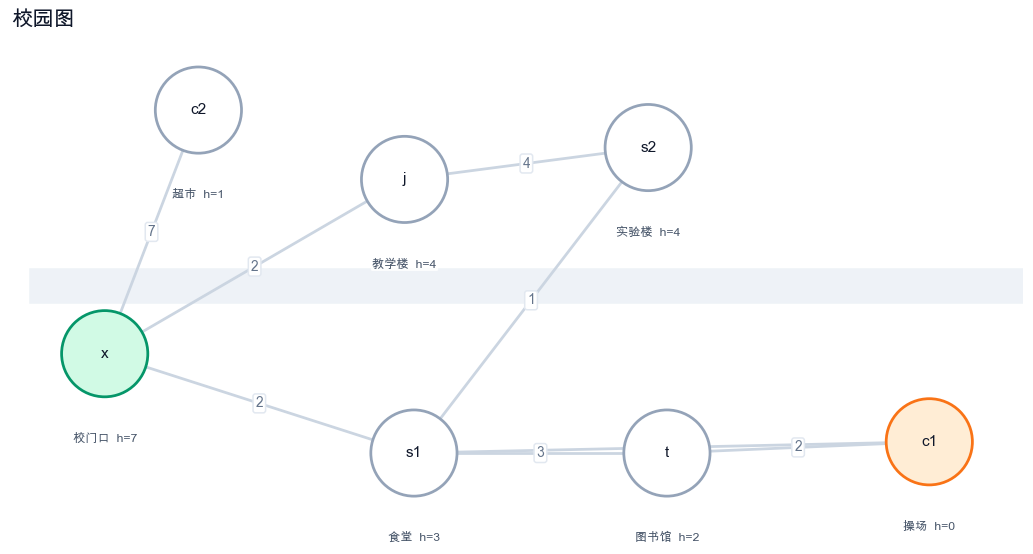

In [5]:
# 绘制校园路径图：高亮已访问节点和最终路线。
layout = {
    "x": (0.25, 1.15),
    "c2": (0.75, 2.45),
    "j": (1.85, 2.08),
    "s2": (3.15, 2.25),
    "s1": (1.9, 0.62),
    "t": (3.25, 0.62),
    "c1": (4.65, 0.68),
}


def edge_key(a, b):
    return tuple(sorted((a, b)))


def path_edges(path):
    return {edge_key(path[i], path[i + 1]) for i in range(len(path) - 1)}


def draw_search_result(path=None, trace=None, title="校园搜索图"):
    path = path or []
    active_edges = path_edges(path)
    visited_nodes = set(path)
    if trace is not None and not trace.empty:
        visited_nodes.update(trace["取出节点"].tolist())

    fig, ax = plt.subplots(figsize=(9.5, 5.1))
    ax.set_facecolor("#fbfcfd")
    ax.add_patch(
        plt.Rectangle((-0.15, 1.42), 5.35, 0.18, color="#eef2f7", zorder=0)
    )

    drawn_edges = set()
    for a, neighbors in adj.items():
        for b, cost in neighbors:
            key = edge_key(a, b)
            if key in drawn_edges:
                continue
            drawn_edges.add(key)
            x1, y1 = layout[a]
            x2, y2 = layout[b]
            is_path = key in active_edges
            ax.plot(
                [x1, x2],
                [y1, y2],
                color="#2563eb" if is_path else "#cbd5e1",
                linewidth=3.2 if is_path else 1.8,
                solid_capstyle="round",
                zorder=2 if is_path else 1,
            )
            ax.text(
                (x1 + x2) / 2,
                (y1 + y2) / 2,
                str(cost),
                ha="center",
                va="center",
                fontsize=9,
                color="#1d4ed8" if is_path else "#64748b",
                bbox={"boxstyle": "round,pad=0.18", "fc": "white", "ec": "#e2e8f0"},
                zorder=4,
            )

    for node, (x, y) in layout.items():
        is_start = node == start
        is_goal = node == goal
        is_visited = node in visited_nodes
        face = "#eff6ff" if is_visited else "#ffffff"
        edge = "#2563eb" if is_visited else "#94a3b8"
        if is_start:
            face, edge = "#d1fae5", "#059669"
        if is_goal:
            face, edge = "#ffedd5", "#f97316"
        circle = plt.Circle((x, y), 0.23, facecolor=face, edgecolor=edge, linewidth=1.8, zorder=5)
        ax.add_patch(circle)
        ax.text(x, y, node, ha="center", va="center", fontweight="bold", color="#0f172a", zorder=6)
        ax.text(
            x,
            y - 0.42,
            f"{graph['nodes'][node]['name']}  h={h[node]}",
            ha="center",
            va="top",
            fontsize=8,
            color="#475569",
            bbox={"boxstyle": "round,pad=0.12", "fc": "white", "ec": "none", "alpha": 0.85},
        )

    if path:
        total = path_cost(path)
        ax.text(
            0.04,
            0.05,
            f"path: {' -> '.join(path)}   cost={total}",
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=10,
            color="#334155",
            bbox={"boxstyle": "round,pad=0.32", "fc": "white", "ec": "#e2e8f0"},
        )

    ax.set_title(title, loc="left", fontsize=14, fontweight="bold", color="#0f172a")
    ax.set_xlim(-0.25, 5.15)
    ax.set_ylim(0.18, 2.85)
    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


draw_search_result(title="校园图")

## 1. 搜索算法

In [6]:
# 路径辅助函数：回溯路线、计算总代价、格式化候选队列。
def reconstruct_path(parent, goal):
    path = []
    current = goal
    while current is not None:
        path.append(current)
        current = parent.get(current)
    return list(reversed(path))


def path_cost(path):
    total = 0
    for a, b in zip(path, path[1:]):
        for nbr, cost in adj[a]:
            if nbr == b:
                total += cost
                break
    return total


def frontier_text(items):
    return " | ".join(items) if items else "∅"

In [7]:
# DFS：使用栈；最后加入的候选节点最先展开。
def dfs(start, goal, adj):
    stack = [(start, [start], 0)]
    visited = set()
    rows = []
    step = 0

    while stack:
        step += 1
        before = [item[0] for item in stack]
        node, path, cost = stack.pop()

        if node in visited:
            rows.append({
                "步骤": step,
                "frontier取出前": frontier_text(before),
                "取出节点": node,
                "新增候选": "已访问，跳过",
                "当前路径": "→".join(path),
                "已访问": "→".join(sorted(visited)),
            })
            continue

        visited.add(node)
        if node == goal:
            rows.append({
                "步骤": step,
                "frontier取出前": frontier_text(before),
                "取出节点": node,
                "新增候选": "到达目标",
                "当前路径": "→".join(path),
                "已访问": "→".join(sorted(visited)),
            })
            return path, pd.DataFrame(rows)

        pushed = []
        for nbr, edge_cost in reversed(adj[node]):
            if nbr not in visited:
                stack.append((nbr, path + [nbr], cost + edge_cost))
                pushed.append(f"{nbr}(cost={cost + edge_cost})")

        rows.append({
            "步骤": step,
            "frontier取出前": frontier_text(before),
            "取出节点": node,
            "新增候选": frontier_text(pushed),
            "当前路径": "→".join(path),
            "已访问": "→".join(sorted(visited)),
        })

    return [], pd.DataFrame(rows)

In [8]:
# BFS：使用队列；按边数层级一圈一圈向外扩展。
def bfs(start, goal, adj):
    queue = deque([(start, [start], 0)])
    discovered = {start}
    rows = []
    step = 0

    while queue:
        step += 1
        before = [item[0] for item in queue]
        node, path, cost = queue.popleft()

        if node == goal:
            rows.append({
                "步骤": step,
                "frontier取出前": frontier_text(before),
                "取出节点": node,
                "新增候选": "到达目标",
                "当前路径": "→".join(path),
                "已发现": "→".join(sorted(discovered)),
            })
            return path, pd.DataFrame(rows)

        added = []
        for nbr, edge_cost in adj[node]:
            if nbr not in discovered:
                discovered.add(nbr)
                queue.append((nbr, path + [nbr], cost + edge_cost))
                added.append(nbr)

        rows.append({
            "步骤": step,
            "frontier取出前": frontier_text(before),
            "取出节点": node,
            "新增候选": frontier_text(added),
            "当前路径": "→".join(path),
            "已发现": "→".join(sorted(discovered)),
        })

    return [], pd.DataFrame(rows)

In [9]:
# UCS：按累计代价 g 排序；优先展开当前最便宜的路线。
def ucs(start, goal, adj):
    frontier = [(0, start, [start])]
    best_cost = {start: 0}
    visited = set()
    rows = []
    step = 0

    while frontier:
        step += 1
        before = [f"{item[1]}(g={item[0]})" for item in sorted(frontier)]
        cost, node, path = heapq.heappop(frontier)

        if node in visited:
            continue
        visited.add(node)

        if node == goal:
            rows.append({
                "步骤": step,
                "frontier取出前": frontier_text(before),
                "取出节点": node,
                "新增候选": "到达目标",
                "当前路径": "→".join(path),
                "g": cost,
            })
            return path, pd.DataFrame(rows)

        added = []
        for nbr, edge_cost in adj[node]:
            new_cost = cost + edge_cost
            if nbr in visited or new_cost >= best_cost.get(nbr, float("inf")):
                continue
            best_cost[nbr] = new_cost
            heapq.heappush(frontier, (new_cost, nbr, path + [nbr]))
            added.append(f"{nbr}(g={new_cost})")

        rows.append({
            "步骤": step,
            "frontier取出前": frontier_text(before),
            "取出节点": node,
            "新增候选": frontier_text(added),
            "当前路径": "→".join(path),
            "g": cost,
        })

    return [], pd.DataFrame(rows)

In [10]:
# Greedy：只看启发式 h；优先展开看起来更接近目标的节点。
def greedy(start, goal, adj, h):
    frontier = [(h[start], 0, start, [start])]
    visited = set()
    rows = []
    step = 0

    while frontier:
        step += 1
        before = [f"{item[2]}(h={item[0]})" for item in sorted(frontier)]
        h_value, cost, node, path = heapq.heappop(frontier)

        if node in visited:
            continue
        visited.add(node)

        if node == goal:
            rows.append({
                "步骤": step,
                "frontier取出前": frontier_text(before),
                "取出节点": node,
                "新增候选": "到达目标",
                "当前路径": "→".join(path),
                "h": h_value,
                "实际代价": cost,
            })
            return path, pd.DataFrame(rows)

        added = []
        for nbr, edge_cost in adj[node]:
            if nbr in visited:
                continue
            new_cost = cost + edge_cost
            heapq.heappush(frontier, (h[nbr], new_cost, nbr, path + [nbr]))
            added.append(f"{nbr}(h={h[nbr]})")

        rows.append({
            "步骤": step,
            "frontier取出前": frontier_text(before),
            "取出节点": node,
            "新增候选": frontier_text(added),
            "当前路径": "→".join(path),
            "h": h_value,
            "实际代价": cost,
        })

    return [], pd.DataFrame(rows)

In [11]:
# A*：按 f=g+h 排序；同时考虑已走代价和剩余距离估计。
def astar(start, goal, adj, h):
    frontier = [(h[start], h[start], 0, start, [start])]
    best_cost = {start: 0}
    visited = set()
    rows = []
    step = 0

    while frontier:
        step += 1
        before = [f"{item[3]}(f={item[0]}, g={item[2]}, h={item[1]})" for item in sorted(frontier)]
        f_value, h_value, cost, node, path = heapq.heappop(frontier)

        if node in visited:
            continue
        visited.add(node)

        if node == goal:
            rows.append({
                "步骤": step,
                "frontier取出前": frontier_text(before),
                "取出节点": node,
                "新增候选": "到达目标",
                "当前路径": "→".join(path),
                "g": cost,
                "h": h_value,
                "f": f_value,
            })
            return path, pd.DataFrame(rows)

        added = []
        for nbr, edge_cost in adj[node]:
            new_cost = cost + edge_cost
            if nbr in visited or new_cost >= best_cost.get(nbr, float("inf")):
                continue
            best_cost[nbr] = new_cost
            new_h = h[nbr]
            new_f = new_cost + new_h
            heapq.heappush(frontier, (new_f, new_h, new_cost, nbr, path + [nbr]))
            added.append(f"{nbr}(f={new_f}, g={new_cost}, h={new_h})")

        rows.append({
            "步骤": step,
            "frontier取出前": frontier_text(before),
            "取出节点": node,
            "新增候选": frontier_text(added),
            "当前路径": "→".join(path),
            "g": cost,
            "h": h_value,
            "f": f_value,
        })

    return [], pd.DataFrame(rows)

## 2. 逐个运行并查看过程

### 2.1 DFS

,步骤,frontier取出前,取出节点,新增候选,当前路径,已访问
0,1,x,x,s1(cost=2) | j(cost=2) | c2(cost=7),x,x
1,2,s1 | j | c2,c2,∅,x→c2,c2→x
2,3,s1 | j,j,s2(cost=6),x→j,c2→j→x
3,4,s1 | s2,s2,s1(cost=7),x→j→s2,c2→j→s2→x
4,5,s1 | s1,s1,t(cost=10) | c1(cost=13),x→j→s2→s1,c2→j→s1→s2→x
5,6,s1 | t | c1,c1,到达目标,x→j→s2→s1→c1,c1→c2→j→s1→s2→x


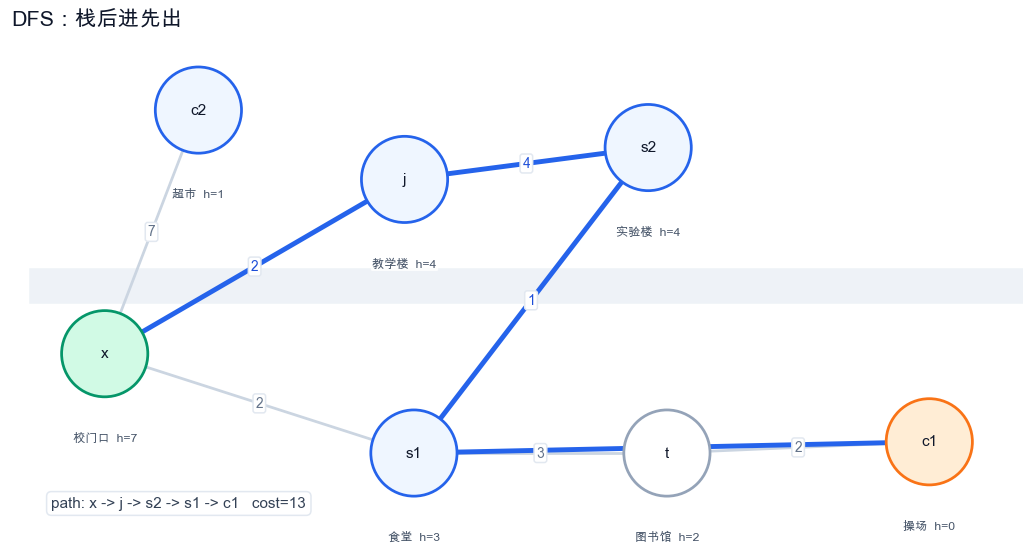

In [12]:
# 运行 DFS：查看栈的展开过程和最终路线。
dfs_path, dfs_trace = dfs(start, goal, adj)
display(dfs_trace)
draw_search_result(dfs_path, dfs_trace, "DFS：栈后进先出")

### 2.2 BFS

,步骤,frontier取出前,取出节点,新增候选,当前路径,已发现
0,1,x,x,c2 | j | s1,x,c2→j→s1→x
1,2,c2 | j | s1,c2,∅,x→c2,c2→j→s1→x
2,3,j | s1,j,s2,x→j,c2→j→s1→s2→x
3,4,s1 | s2,s1,c1 | t,x→s1,c1→c2→j→s1→s2→t→x
4,5,s2 | c1 | t,s2,∅,x→j→s2,c1→c2→j→s1→s2→t→x
5,6,c1 | t,c1,到达目标,x→s1→c1,c1→c2→j→s1→s2→t→x


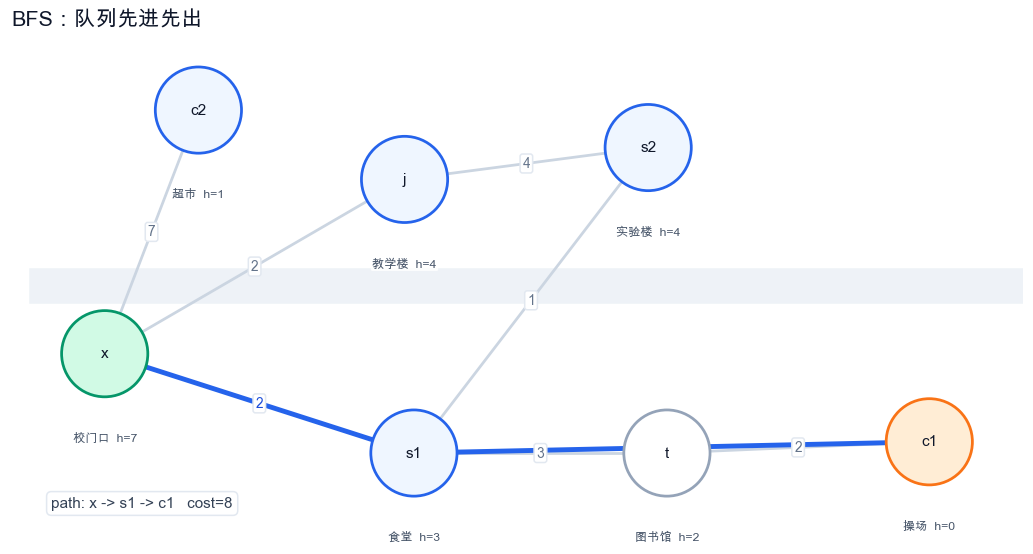

In [13]:
# 运行 BFS：查看队列的展开过程和最终路线。
bfs_path, bfs_trace = bfs(start, goal, adj)
display(bfs_trace)
draw_search_result(bfs_path, bfs_trace, "BFS：队列先进先出")

### 2.3 UCS

,步骤,frontier取出前,取出节点,新增候选,当前路径,g
0,1,x(g=0),x,c2(g=7) | j(g=2) | s1(g=2),x,0
1,2,j(g=2) | s1(g=2) | c2(g=7),j,s2(g=6),x→j,2
2,3,s1(g=2) | s2(g=6) | c2(g=7),s1,c1(g=8) | s2(g=3) | t(g=5),x→s1,2
3,4,s2(g=3) | t(g=5) | s2(g=6) | c2(g=7) | c1(g=8),s2,∅,x→s1→s2,3
4,5,t(g=5) | s2(g=6) | c2(g=7) | c1(g=8),t,c1(g=7),x→s1→t,5
5,7,c1(g=7) | c2(g=7) | c1(g=8),c1,到达目标,x→s1→t→c1,7


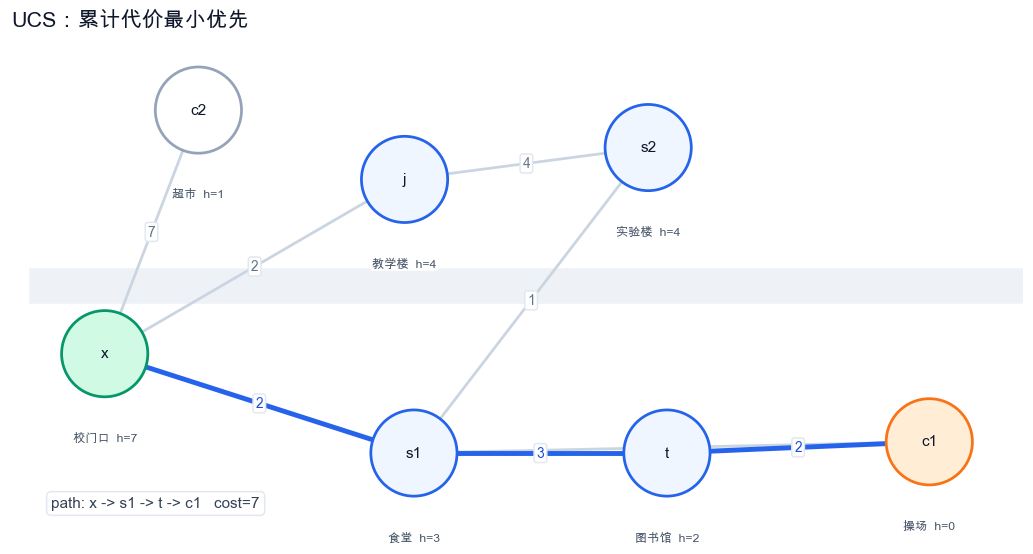

In [14]:
# 运行 UCS：查看按累计代价 g 选择节点的过程。
ucs_path, ucs_trace = ucs(start, goal, adj)
display(ucs_trace)
draw_search_result(ucs_path, ucs_trace, "UCS：累计代价最小优先")

### 2.4 Greedy

,步骤,frontier取出前,取出节点,新增候选,当前路径,h,实际代价
0,1,x(h=7),x,c2(h=1) | j(h=4) | s1(h=3),x,7,0
1,2,c2(h=1) | s1(h=3) | j(h=4),c2,∅,x→c2,1,7
2,3,s1(h=3) | j(h=4),s1,c1(h=0) | s2(h=4) | t(h=2),x→s1,3,2
3,4,c1(h=0) | t(h=2) | j(h=4) | s2(h=4),c1,到达目标,x→s1→c1,0,8


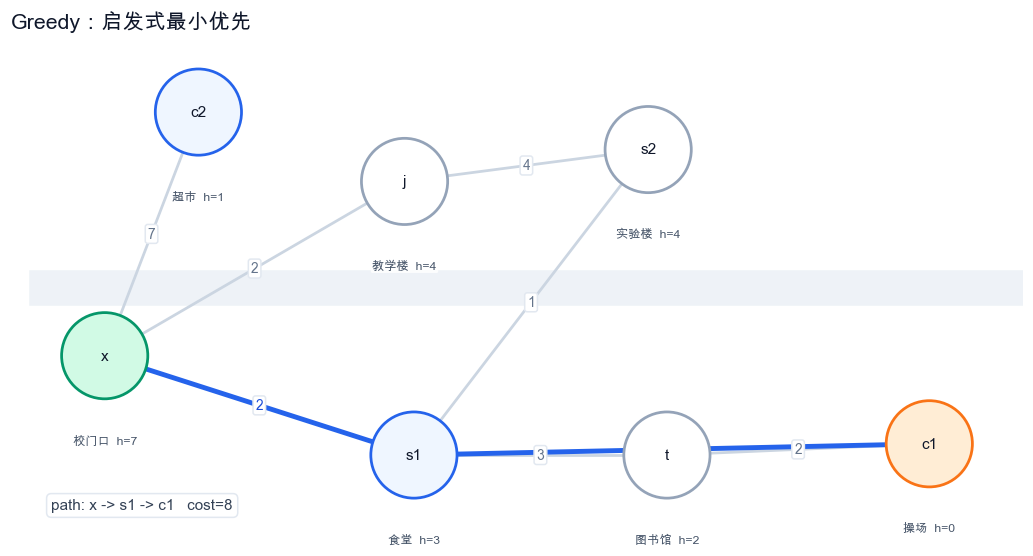

In [15]:
# 运行 Greedy：查看按启发式 h 选择节点的过程。
greedy_path, greedy_trace = greedy(start, goal, adj, h)
display(greedy_trace)
draw_search_result(greedy_path, greedy_trace, "Greedy：启发式最小优先")

### 2.5 A*

,步骤,frontier取出前,取出节点,新增候选,当前路径,g,h,f
0,1,"x(f=7, g=0, h=7)",x,"c2(f=8, g=7, h=1) | j(f=6, g=2, h=4) | s1(f=5,...",x,0,7,7
1,2,"s1(f=5, g=2, h=3) | j(f=6, g=2, h=4) | c2(f=8,...",s1,"c1(f=8, g=8, h=0) | s2(f=7, g=3, h=4) | t(f=7,...",x→s1,2,3,5
2,3,"j(f=6, g=2, h=4) | t(f=7, g=5, h=2) | s2(f=7, ...",j,∅,x→j,2,4,6
3,4,"t(f=7, g=5, h=2) | s2(f=7, g=3, h=4) | c1(f=8,...",t,"c1(f=7, g=7, h=0)",x→s1→t,5,2,7
4,5,"c1(f=7, g=7, h=0) | s2(f=7, g=3, h=4) | c1(f=8...",c1,到达目标,x→s1→t→c1,7,0,7


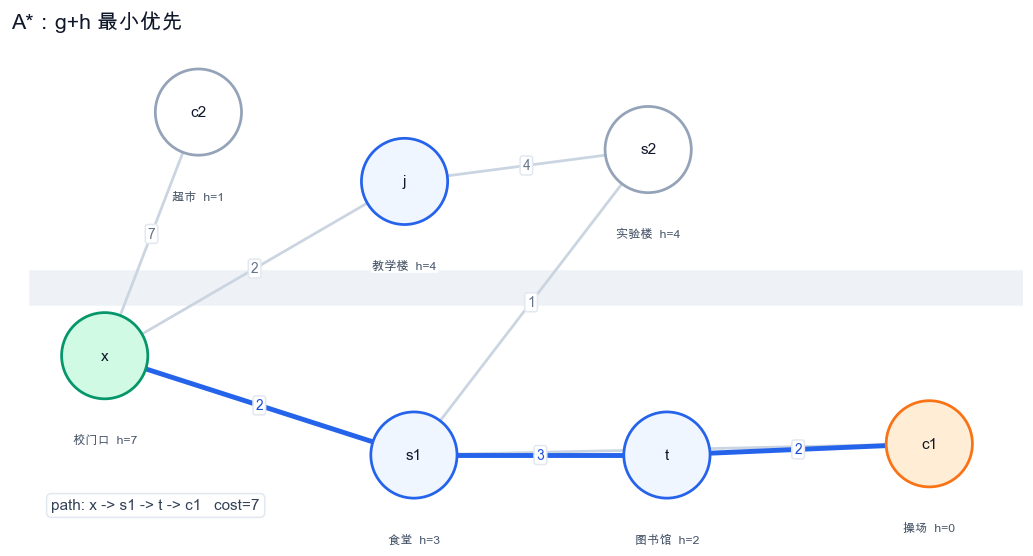

In [16]:
# 运行 A*：查看按 f=g+h 选择节点的过程。
astar_path, astar_trace = astar(start, goal, adj, h)
display(astar_trace)
draw_search_result(astar_path, astar_trace, "A*：g+h 最小优先")

## 3. 结果汇总

In [17]:
# 汇总五种搜索策略的路线、边数和总代价。
summary_df = pd.DataFrame(
    [
        {"算法": "DFS", "路径": "→".join(dfs_path), "边数": len(dfs_path) - 1, "代价": path_cost(dfs_path)},
        {"算法": "BFS", "路径": "→".join(bfs_path), "边数": len(bfs_path) - 1, "代价": path_cost(bfs_path)},
        {"算法": "UCS", "路径": "→".join(ucs_path), "边数": len(ucs_path) - 1, "代价": path_cost(ucs_path)},
        {"算法": "Greedy", "路径": "→".join(greedy_path), "边数": len(greedy_path) - 1, "代价": path_cost(greedy_path)},
        {"算法": "A*", "路径": "→".join(astar_path), "边数": len(astar_path) - 1, "代价": path_cost(astar_path)},
    ]
)
display(summary_df)

,算法,路径,边数,代价
0,DFS,x→j→s2→s1→c1,4,13
1,BFS,x→s1→c1,2,8
2,UCS,x→s1→t→c1,3,7
3,Greedy,x→s1→c1,2,8
4,A*,x→s1→t→c1,3,7
